# Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor, plot_tree

import warnings
warnings.filterwarnings('ignore')

# Create a non-linear dataset

In [2]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3 * X[:, 0]**2 + 0.05 * np.random.randn(100)

In [3]:
df = pd.DataFrame()
df['X'] = X.reshape(100)
df['y'] = y

In [4]:
df.head()

,X,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986


In [5]:
df.shape

(100, 2)

# View the data

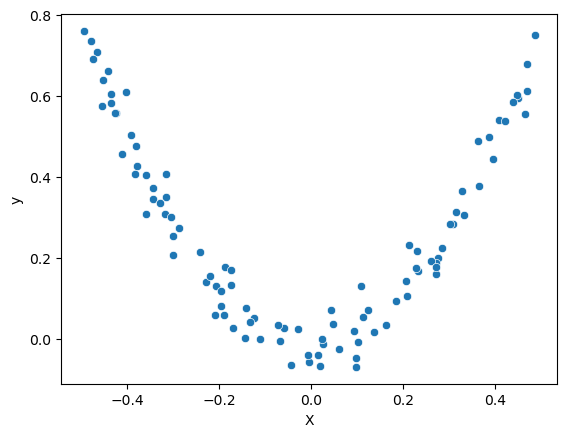

In [6]:
sns.scatterplot(data=df, x=df['X'], y=df['y']);

# Gradient Boosting Regressor (from scratch)

## Model 1 

### Constant prediction (mean of target variable)

In [7]:
df['pred1'] = df['y'].mean()

In [8]:
df.head()

,X,y,pred1
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458


### Calculate the residuals for model 1

In [9]:
df['res1'] = df['y'] - df['pred1']

In [10]:
df.head()

,X,y,pred1,res1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528


### Best Fit Line

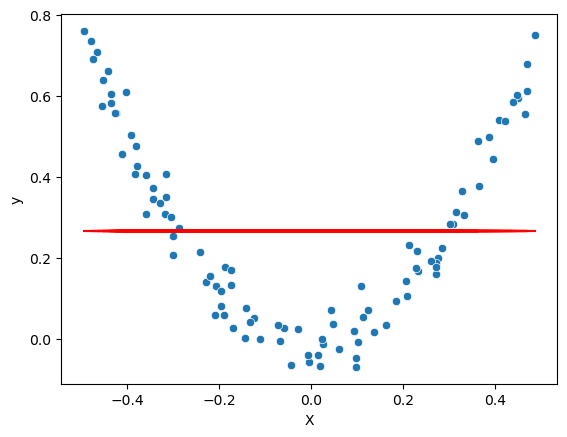

In [11]:
sns.scatterplot(data=df, x=df['X'], y=df['y'])
plt.plot(df['X'], df['pred1'], color='red');

## Model 2

### Fit a Decision Tree

In [12]:
dt1 = DecisionTreeRegressor(max_leaf_nodes=8)

In [13]:
# Inputs - X, Output - residual from Model 1
dt1.fit(df['X'].values.reshape(100, 1), df['res1'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

### View the tree

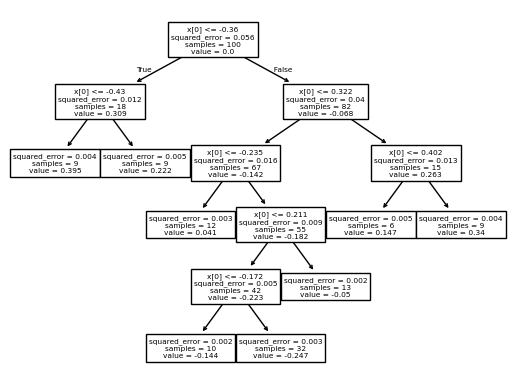

In [14]:
plot_tree(dt1);

### Calculate the residuals for Model 2

In [15]:
# Generate testing data
X_test = np.linspace(-0.5, 0.5, 500)

In [16]:
# y_pred = m1 + m2
y_pred = 0.265458 + dt1.predict(X_test.reshape(500, 1))

In [17]:
# Overall prediction m1 + m2
df['pred2'] = 0.265458 + dt1.predict(df['X'].values.reshape(100, 1))

In [18]:
df.head()

,X,y,pred1,res1,pred2
0,-0.125460,0.051573,0.265458,-0.213885,0.018319
1,0.450714,0.594480,0.265458,0.329021,0.605884
2,0.231994,0.166052,0.265458,-0.099407,0.215784
3,0.098658,-0.070178,0.265458,-0.335636,0.018319
4,-0.343981,0.343986,0.265458,0.078528,0.305964


### Best Fit Line

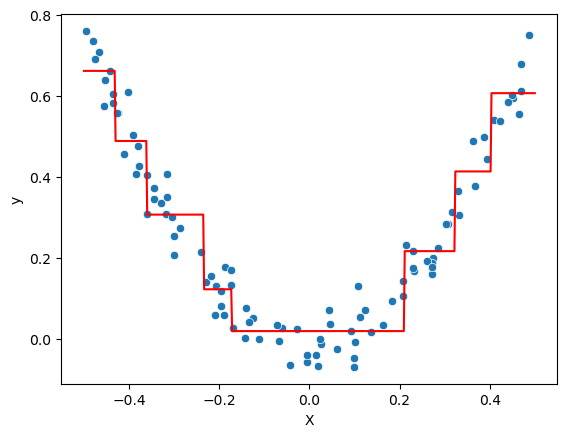

In [19]:
sns.scatterplot(data=df, x=df['X'], y=df['y'])
plt.plot(X_test, y_pred, color='red');

In [20]:
df['res2'] = df['y'] - df['pred2']

In [21]:
df.head()

,X,y,pred1,res1,pred2,res2
0,-0.125460,0.051573,0.265458,-0.213885,0.018319,0.033254
1,0.450714,0.594480,0.265458,0.329021,0.605884,-0.011404
2,0.231994,0.166052,0.265458,-0.099407,0.215784,-0.049732
3,0.098658,-0.070178,0.265458,-0.335636,0.018319,-0.088497
4,-0.343981,0.343986,0.265458,0.078528,0.305964,0.038022


# Generic Function

In [22]:
def gradient_boost(X, y, number, lr, count=1, regs=[], foo=None):

  if number == 0:
    return 
  else:
    # do gradient boosting

    if count > 1:
      y = y - regs[-1].predict(X)
    else:
      foo = y

    tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
    tree_reg.fit(X, y)

    regs.append(tree_reg)

    x1 = np.linspace(-0.5, 0.5, 500)
    y_pred = sum(lr * regressor.predict(x1.reshape(-1, 1)) for regressor in regs)

    print(number)
    plt.figure()
    plt.plot(x1, y_pred, linewidth=2)
    plt.plot(X[:, 0], foo,"r.")
    plt.show()

    gradient_boost(X,y,number-1,lr,count+1,regs,foo=foo)

5


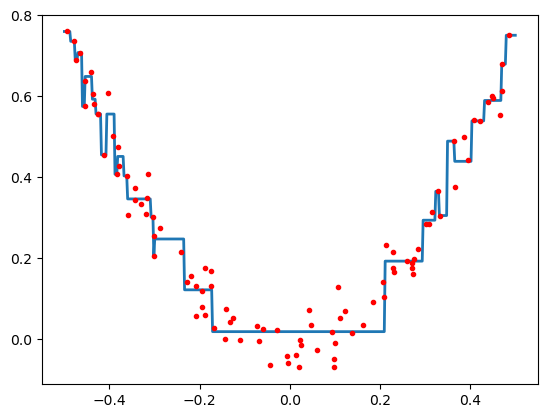

4


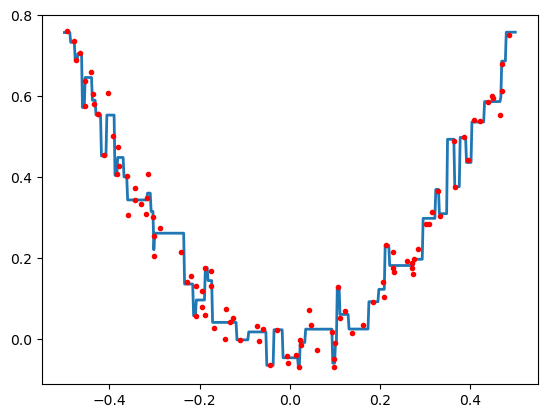

3


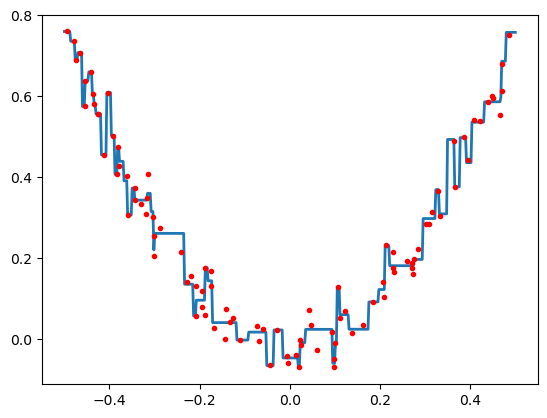

2


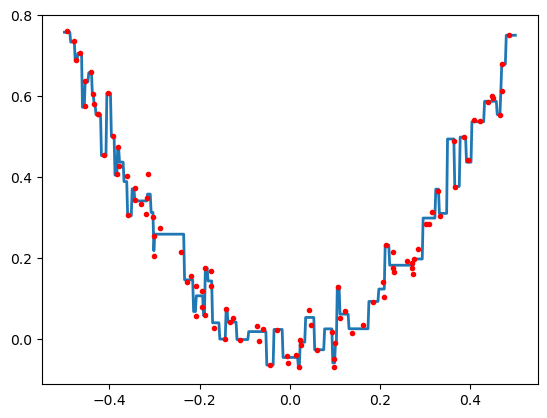

1


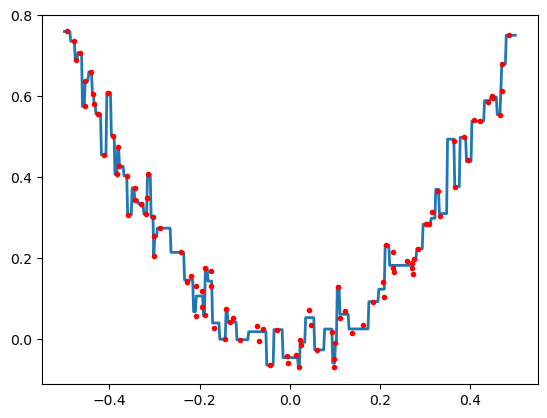

In [23]:
np.random.seed(42)
X_new = np.random.rand(100, 1) - 0.5
y_new = 3 * X_new[:, 0]**2 + 0.05 * np.random.randn(100)
gradient_boost(X_new, y_new, 5, lr=1)